<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<center><font size=10>Artificial Intelligence and Machine Learning</font></center>
<center><font size=6>Ensemble Techniques and Model Tuning</font></center>

<center><img src="https://images.pexels.com/photos/7235894/pexels-photo-7235894.jpeg?auto=compress&cs=tinysrgb&w=1260&h=750&dpr=2" width="800" height="500"></center>

<center><font size=6>Visa Approval Facilitation</font></center>

# **Problem Statement**

## Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

## Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data  scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

* Facilitate the process of visa approvals.
* Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

## Data Description

The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage:  Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position
* case_status:  Flag indicating if the Visa was certified or denied

## Note: This is a sample solution for the project. Projects will NOT be graded on the basis of how well the submission matches this sample solution. Projects will be graded on the basis of the rubric only.

# **Importing necessary libraries**

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 xgboost==3.0.5 -q --user

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 9.5 MB/s eta 0:00:00


**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# **Loading the dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# After running this cell and mounting your Drive, please update the 'file_path' variable below
# with the actual path to your dataset (e.g., '/content/drive/MyDrive/your_dataset.csv')
file_path = '/content/drive/MyDrive/EasyVisa.csv'
df = pd.read_csv(file_path)
df = df.copy()
print('Dataset loaded successfully!')

Mounted at /content/drive
Dataset loaded successfully!


# **Overview of the Dataset**

* Observations

* Sanity checks

In [ ]:
print("Dataset Shape:", df.shape)
print("\nTarget Distribution:")
print(df["case_status"].value_counts(normalize=True))
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (25480, 10)

Target Distribution:
case_status
1    0.667896
0    0.332104
Name: proportion, dtype: float64

Missing Values:
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
full_time_position       0
case_status              0
annual_wage              0
dtype: int64


In [ ]:
# Basic structure checks

print("Shape of dataset:", df.shape)
print("\nColumn names:")
display(df.columns)

print("\nData types:")
display(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["case_status"].value_counts())

Shape of dataset: (25480, 12)

Column names:


Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')


Data types:


,0
case_id,object
continent,object
education_of_employee,object
has_job_experience,object
requires_job_training,object
no_of_employees,int64
yr_of_estab,int64
region_of_employment,object
prevailing_wage,float64
unit_of_wage,object



First 5 rows:


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified



Duplicate rows: 0

Target distribution:


,count
case_status,
Certified,17018
Denied,8462


Observations

* The dataset contains 25,480 rows and 12 columns.

* The dataset consists of both categorical and numerical features.

* No duplicate records were found.

* The target variable (case_status) contains two classes: Certified and Denied.

* The dataset appears moderately imbalanced, with Certified cases forming the majority.

# <a name='link2'>**Exploratory Data Analysis (EDA)**</a>

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Leading Questions**

What is the distribution of visa case statuses (certified vs. denied)?


1. What is the distribution of visa case statuses (certified vs. denied)?
2. How does the education level of employees impact visa approval rates?
3. Is there a significant difference in visa approval rates between employees with and without prior job experience?
4. How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?
5. Do certain regions in the US have higher visa approval rates compared to others?
6. How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?
7. Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?

Shape: (25480, 12)


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied



Missing values (top):


,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0



Target distribution:


,count
case_status,
Certified,17018
Denied,8462


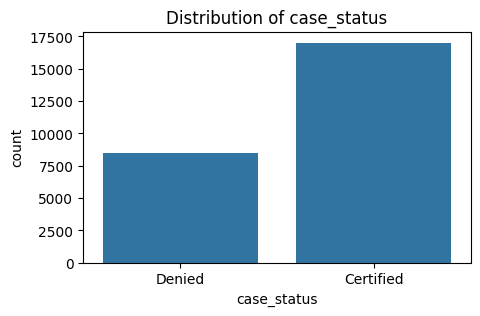

In [ ]:
#Leading Q1: certified vs denied distribution
def approval_rate_bar(df, col, target="case_status"):
    tmp = (
        df.groupby(col)[target]
          .apply(lambda s: (s == "Certified").mean())
          .sort_values(ascending=False)
          .reset_index(name="approval_rate")
    )
    plt.figure(figsize=(8, 4))
    sns.barplot(data=tmp, x=col, y="approval_rate")
    plt.ylim(0, 1)
    plt.title(f"Visa approval rate by {col}")
    plt.xticks(rotation=30, ha="right")
    plt.show()
    return tmp

def approval_rate_by_bins(df, col, bins, target="case_status"):
    binned = pd.cut(df[col], bins=bins, include_lowest=True)
    tmp = (
        df.groupby(binned)[target]
          .apply(lambda s: (s == "Certified").mean())
          .reset_index(name="approval_rate")
    )
    plt.figure(figsize=(10, 4))
    sns.barplot(data=tmp, x=col, y="approval_rate")
    plt.ylim(0, 1)
    plt.title(f"Visa approval rate by {col} (binned)")
    plt.xticks(rotation=30, ha="right")
    plt.show()
    return tmp

# quick sanity check
print("Shape:", df.shape)
display(df.head(3))

print("\nMissing values (top):")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nTarget distribution:")
display(df["case_status"].value_counts())
plt.figure(figsize=(5,3))
sns.countplot(data=df, x="case_status")
plt.title("Distribution of case_status")
plt.show()

**Case Status Distribution**

* The majority of visa applications are Certified, accounting for
approximately 66.8% of total cases (nearly two-thirds), while Denied cases represent about 33.2% (approximately one-third).

* This indicates a moderate class imbalance in the dataset, with a higher proportion of certified cases compared to denied cases.

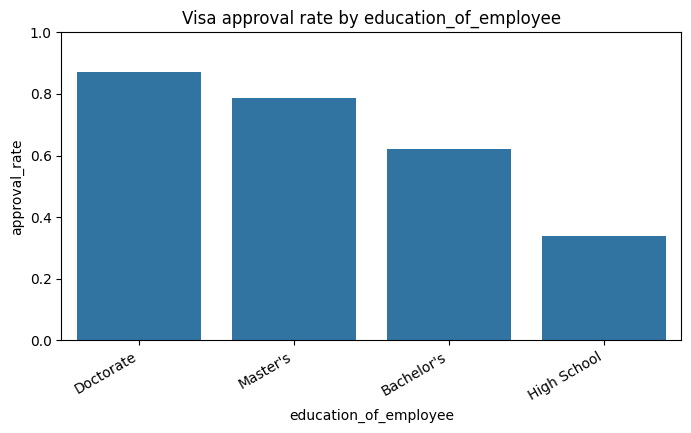

,education_of_employee,approval_rate
0,Doctorate,0.872263
1,Master's,0.786278
2,Bachelor's,0.622142
3,High School,0.340351


In [ ]:
# Leading Q2: education vs approval
edu_tbl = approval_rate_bar(df, "education_of_employee")
display(edu_tbl)

**Education Level Distribution**

* The analysis shows a clear positive relationship between education level and visa approval rates. Applicants with higher educational qualifications (such as Master’s and Doctorate degrees) exhibit higher certification rates compared to those with lower education levels. Conversely, applicants with lower education levels show relatively lower approval rates.

* This suggests that higher educational attainment positively influences visa certification outcomes, possibly reflecting employer preference for highly skilled and specialized talent.

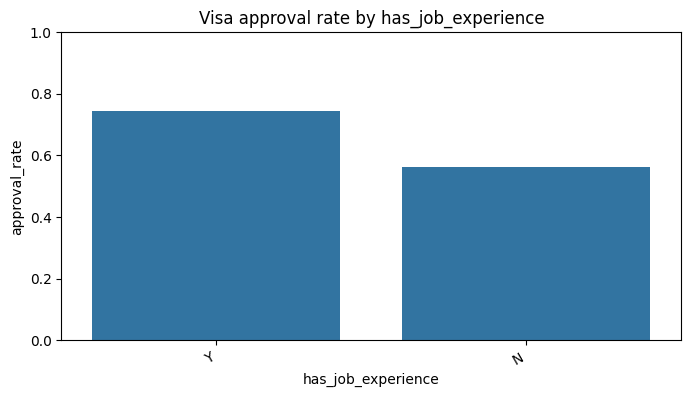

,has_job_experience,approval_rate
0,Y,0.744764
1,N,0.561341


In [ ]:
# Leading Q3: job experience vs approval
exp_tbl = approval_rate_bar(df, "has_job_experience")
display(exp_tbl)

**Job Expereience Distribution**

* Applicants with prior job experience have approximately 18 percentage points higher visa certification rates compared to applicants without job experience. This indicates a strong positive relationship between job experience and visa approval outcomes.

* The results suggest that prior work experience significantly improves the likelihood of visa certification, possibly because experienced candidates are perceived as lower risk and more immediately productive by employers.

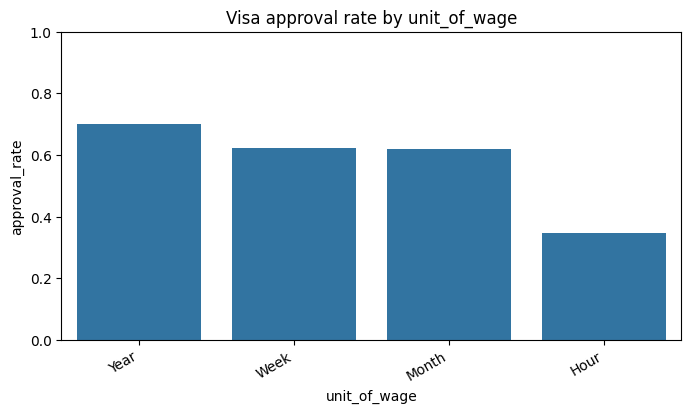

,unit_of_wage,approval_rate
0,Year,0.698850
1,Week,0.621324
2,Month,0.617978
3,Hour,0.346314



Prevailing wage bins (within Hour)


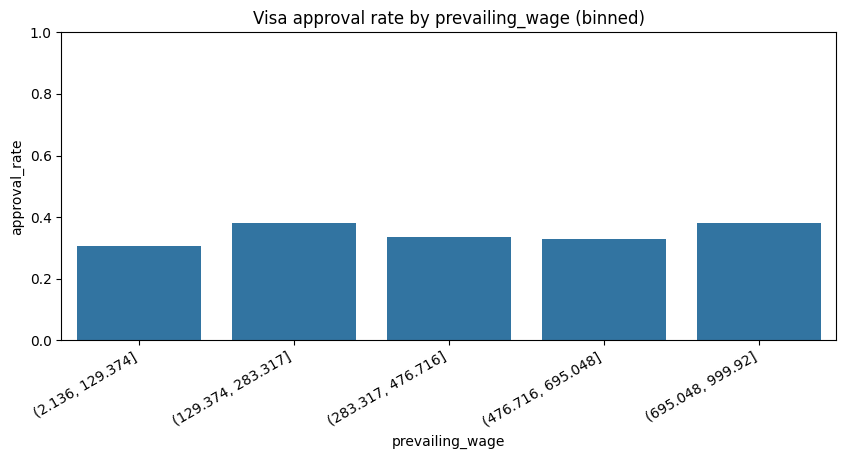

,prevailing_wage,approval_rate
0,"(2.136, 129.374]",0.307870
1,"(129.374, 283.317]",0.380510
2,"(283.317, 476.716]",0.334107
3,"(476.716, 695.048]",0.329466
4,"(695.048, 999.92]",0.379630



Prevailing wage bins (within Year)


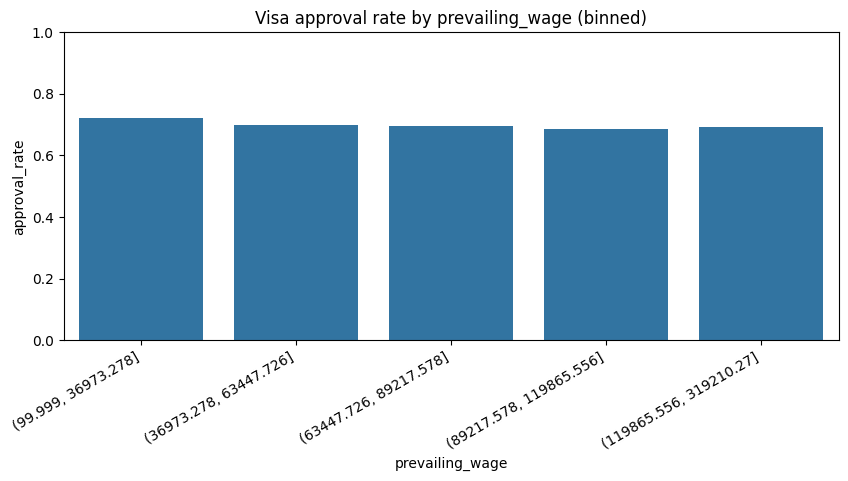

,prevailing_wage,approval_rate
0,"(99.999, 36973.278]",0.721533
1,"(36973.278, 63447.726]",0.697953
2,"(63447.726, 89217.578]",0.697082
3,"(89217.578, 119865.556]",0.686193
4,"(119865.556, 319210.27]",0.691487



Prevailing wage bins (within Week)


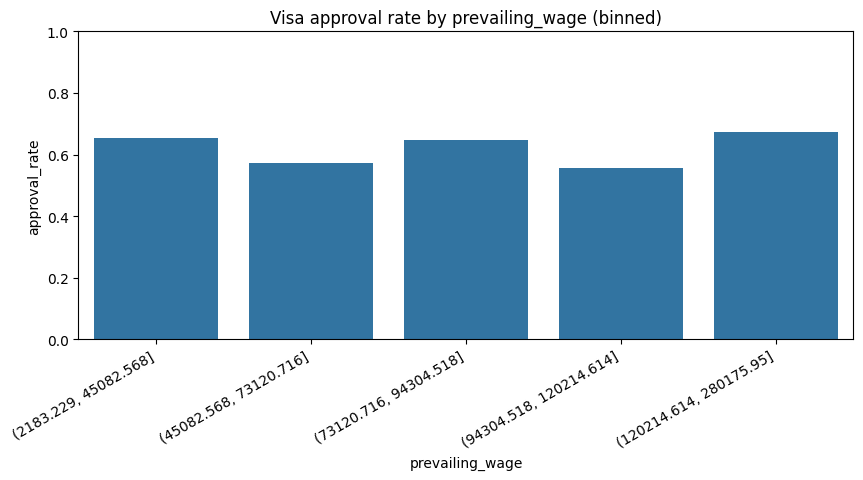

,prevailing_wage,approval_rate
0,"(2183.229, 45082.568]",0.654545
1,"(45082.568, 73120.716]",0.574074
2,"(73120.716, 94304.518]",0.648148
3,"(94304.518, 120214.614]",0.555556
4,"(120214.614, 280175.95]",0.672727



Prevailing wage bins (within Month)


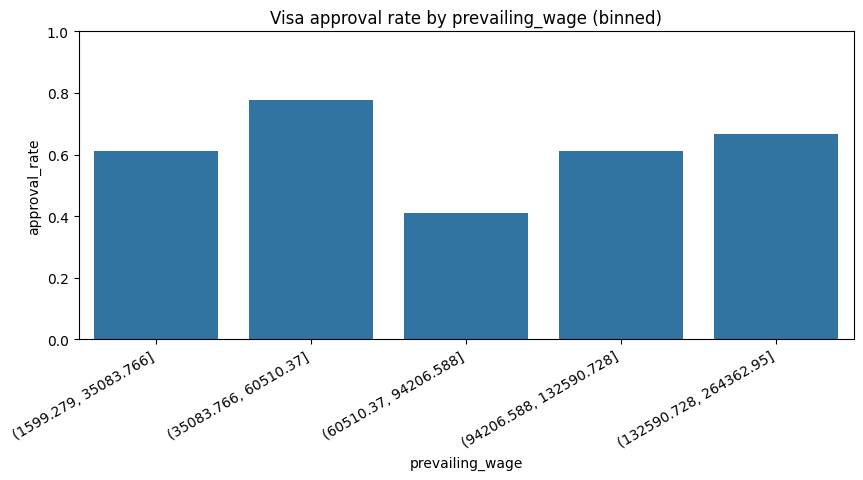

,prevailing_wage,approval_rate
0,"(1599.279, 35083.766]",0.611111
1,"(35083.766, 60510.37]",0.777778
2,"(60510.37, 94206.588]",0.411765
3,"(94206.588, 132590.728]",0.611111
4,"(132590.728, 264362.95]",0.666667


In [ ]:
# Leading Q4: prevailing wage vs approval
# wage unit matters. We'll do two views:
#   (a) approval by unit_of_wage
#   (b) approval by prevailing_wage within each unit (binned)

unit_tbl = approval_rate_bar(df, "unit_of_wage")
display(unit_tbl)

# prevailing_wage is numeric; we bin it per unit to keep comparisons meaningful
for unit in df["unit_of_wage"].dropna().unique():
    sub = df[df["unit_of_wage"] == unit].copy()
    if sub["prevailing_wage"].nunique() < 10:
        continue
    bins = np.quantile(sub["prevailing_wage"], [0, .2, .4, .6, .8, 1.0])
    bins = np.unique(bins)
    if len(bins) >= 4:
        print(f"\nPrevailing wage bins (within {unit})")
        tbl = approval_rate_by_bins(sub, "prevailing_wage", bins=bins)
        display(tbl)

**Wage Distribution**

Premise: Since wage units are not directly comparable, wages were analyzed within each unit using quantile-based bins.

**Hourly Wage**

Approval rates range between 30.8% and 38.1% across bins.
While there is slight variation, no strong upward trend is observed. Approval rates remain relatively low overall for hourly wage cases.

**Yearly Wage**

Approval rates are consistently high, ranging between 68.6% and 72.2% across bins.
Interestingly, the lowest yearly wage bin shows the highest approval rate (72.15%), and approval remains relatively stable across wage brackets. This suggests that within yearly wage applications, wage level alone does not drastically change approval likelihood.

**Weekly Wage**

Approval rates fluctuate between 55.6% and 67.3%, with no strictly increasing pattern. This indicates moderate variability but no clear monotonic wage effect.

**Monthly Wage**

Approval rates show noticeable volatility (from 41.2% to 77.8%), likely due to smaller sample sizes within bins. This variability suggests that monthly wage categories may contain fewer observations.

**Insights**

* The unit of wage appears to be a stronger differentiator than wage level within each unit.

* Hourly wage applications have significantly lower certification rates compared to other wage types.

* Within yearly wage cases, approval rates remain consistently high across wage bins.

* Wage amount alone does not show a strictly increasing relationship with approval within each unit.

**Interpretation**

* The results suggest that wage structure (hourly vs yearly) plays a more critical role than incremental wage increases within the same unit. This may reflect regulatory preference for structured, salaried employment arrangements.

* Given these findings, it will be important during preprocessing to normalize wages into a common annual basis to better capture the true effect of compensation on visa approval.



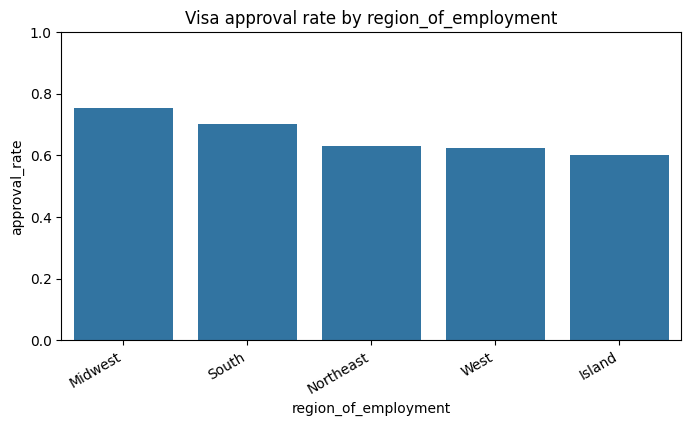

,region_of_employment,approval_rate
0,Midwest,0.755282
1,South,0.700157
2,Northeast,0.629048
3,West,0.622533
4,Island,0.602667


In [ ]:
# Leading Q5: region vs approval
region_tbl = approval_rate_bar(df, "region_of_employment")
display(region_tbl)

**Region Distribution**

* Visa approval rates vary noticeably across different regions of employment in the United States.

* The Midwest region has the highest approval rate at approximately 75.5%, followed by the South at 70.0%. In contrast, the Island region has the lowest approval rate at approximately 60.3%, with the West (62.3%) and Northeast (62.9%) also showing comparatively lower certification rates.

* The difference between the highest (Midwest) and lowest (Island) approval rates is approximately 15 percentage points, indicating meaningful regional variation in visa certification outcomes.

**Interpretation**

* These regional differences may reflect variations in labor demand, industry concentration, employer compliance practices, or wage competitiveness across different geographic areas. Regions such as the Midwest and South may have stronger demand for foreign labor or more structured employment arrangements, leading to higher approval rates.

**Insight**

* Since approval rates differ significantly across regions, region_of_employment is likely to be an important predictive feature in the classification model.

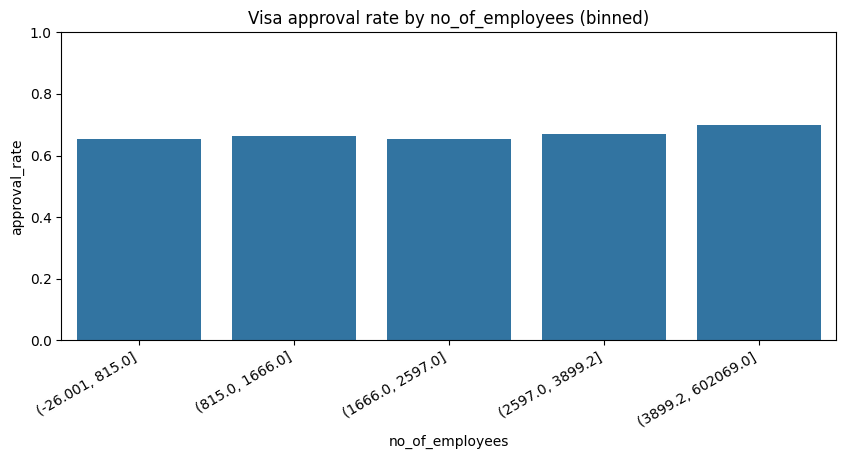

,no_of_employees,approval_rate
0,"(-26.001, 815.0]",0.653341
1,"(815.0, 1666.0]",0.662215
2,"(1666.0, 2597.0]",0.654299
3,"(2597.0, 3899.2]",0.671050
4,"(3899.2, 602069.0]",0.698587


In [ ]:
# Leading Q6: company size vs approval
# Used quantile bins so we don't get tiny sparse groups
bins_emp = np.quantile(df["no_of_employees"], [0, .2, .4, .6, .8, 1.0])
bins_emp = np.unique(bins_emp)
if len(bins_emp) >= 4:
    emp_tbl = approval_rate_by_bins(df, "no_of_employees", bins=bins_emp)
    display(emp_tbl)

Company Size Distribution

* Visa approval rates show a gradual upward trend as company size increases.

* Companies with fewer than 815 employees have an approval rate of approximately 65.3%.

* Mid-sized companies (815–3899 employees) show approval rates ranging between 65.4% and 67.1%.

* The largest companies (above 3899 employees) exhibit the highest approval rate at approximately 69.9%.

**Interpretation**

* This suggests that larger organizations may have slightly higher visa certification success rates. Possible reasons include:

1. Better legal and compliance teams

2. More structured documentation processes

3. Greater financial stability

4. Stronger history of hiring foreign workers

However, the increase in approval rates across bins is gradual rather than dramatic, indicating that company size is likely a moderate predictor rather than a dominant factor.

**Insight**

* Since approval rates increase with company size, no_of_employees may contribute predictive value in the classification model, although its effect appears weaker compared to variables such as wage, education, or region.

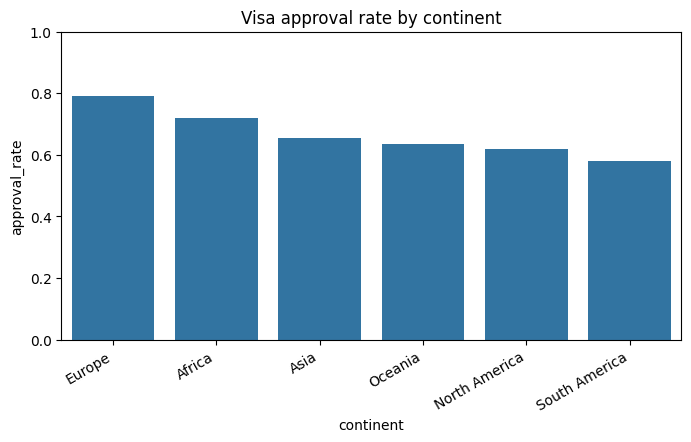

,continent,approval_rate
0,Europe,0.792337
1,Africa,0.720508
2,Asia,0.653105
3,Oceania,0.635417
4,North America,0.618773
5,South America,0.578638


In [ ]:
# Leading Q7: continent vs approval
cont_tbl = approval_rate_bar(df, "continent")
display(cont_tbl)

**Continent Distribution**

**Observation**

* Visa approval rates differ noticeably across continents.

* Europe has the highest approval rate at approximately 79.2%.

* Africa follows with an approval rate of 72.1%.

* Asia and Oceania show moderate approval rates of 65.3% and 63.5%, respectively.

* North America has an approval rate of 61.9%.

* South America has the lowest approval rate at approximately 57.9%.

The difference between the highest (Europe) and lowest (South America) approval rates is approximately 21 percentage points, indicating substantial variation across continents.

**Interpretation**

These differences may reflect variations in:

1. Skill specialization by region

2. Educational distribution

3. Industry alignment with US labor demand

4. Employer sponsorship patterns

However, continent alone does not determine approval; it likely interacts with other factors such as education, experience, and wage levels.

**Insight**

Since approval rates vary significantly across continents, continent is likely to be an important predictive feature in the classification model and may contribute meaningful discriminatory power.

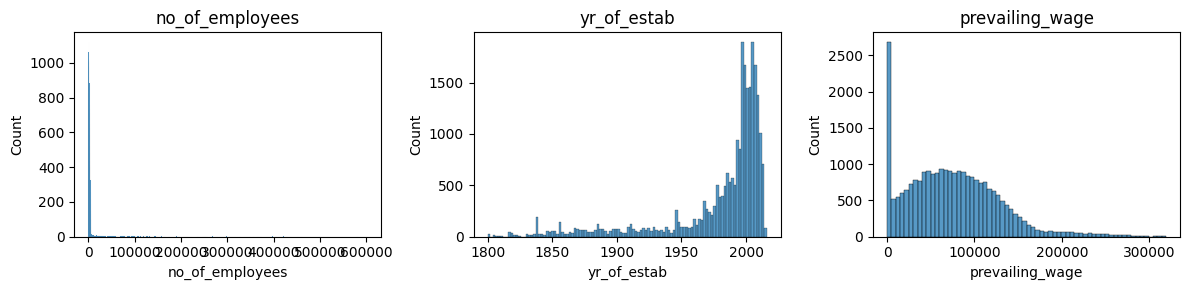

In [ ]:
num_cols = ["no_of_employees", "yr_of_estab", "prevailing_wage"]
plt.figure(figsize=(12, 3))
for i, c in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.histplot(df[c], kde=False)
    plt.title(c)
plt.tight_layout()
plt.show()

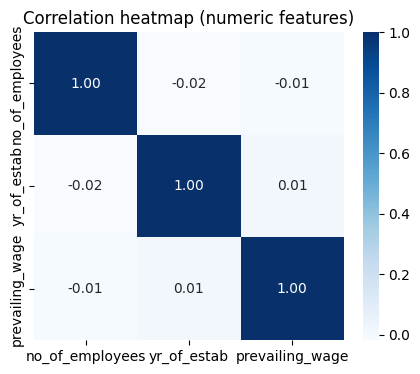

In [ ]:
# Correlation (numeric only)
plt.figure(figsize=(5,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation heatmap (numeric features)")
plt.show()

**Distribution**

* The histograms of no_of_employees, yr_of_estab, and prevailing_wage reveal the following patterns:

* Number of Employees shows a right-skewed distribution, indicating that while most companies are small to mid-sized, a small number of very large firms exist.

* Prevailing Wage also appears right-skewed, suggesting the presence of high-wage outliers.

* Year of Establishment appears relatively spread out, with most companies established in more recent decades.

**Correlation**

* The correlation heatmap indicates:

* There is no strong linear correlation among the numeric features.

* no_of_employees, yr_of_estab, and prevailing_wage exhibit weak to moderate correlations with each other.

* The absence of high correlation values suggests that multicollinearity is not a major concern among these numeric variables.

**Insight**

* Since numeric features do not show strong inter-correlation, they can be safely included in the classification model without significant redundancy issues.

* Additionally, given the skewed nature of some variables, appropriate preprocessing techniques (such as scaling or transformation) may improve model performance.

# **Data Pre-processing**

- Missing value treatment (if needed)
- Feature engineering (if needed)
- Outlier detection and treatment (if needed)
- Preparing data for modeling
- Any other preprocessing steps (if needed)

In [ ]:
# Check missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("Missing values in dataset:")
display(missing_values)

Missing values in dataset:


,0


In [ ]:
df.drop("case_id", axis=1, inplace=True)

* No missing values in dataset
* Dropping case_id as it is not useful for modelling

In [ ]:
df["annual_wage"] = df["prevailing_wage"]

df.loc[df["unit_of_wage"] == "Hourly", "annual_wage"] = df["prevailing_wage"] * 2080
df.loc[df["unit_of_wage"] == "Weekly", "annual_wage"] = df["prevailing_wage"] * 52
df.loc[df["unit_of_wage"] == "Monthly", "annual_wage"] = df["prevailing_wage"] * 12
df.loc[df["unit_of_wage"] == "Yearly", "annual_wage"] = df["prevailing_wage"]

# Drop old wage columns
df.drop(columns=["prevailing_wage", "unit_of_wage"], inplace=True)

* Since wage units (Hourly, Weekly, Monthly, Yearly) are not directly comparable, a new feature annual_wage was created by converting all wages into a common annual scale. This ensures fair comparison and improves model interpretability.

In [ ]:
def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] < lower) | (data[col] > upper)]

print("Outliers in annual_wage:", detect_outliers_iqr(df, "annual_wage").shape[0])
print("Outliers in no_of_employees:", detect_outliers_iqr(df, "no_of_employees").shape[0])

Outliers in annual_wage: 427
Outliers in no_of_employees: 1556


**Outlier Detection and Treatment**

The IQR-based outlier analysis identified:

1. 427 outliers in annual_wage

2. 1556 outliers in no_of_employees

* This indicates that both compensation levels and company size distributions contain extreme values. The higher number of outliers in no_of_employees suggests that a small proportion of companies are significantly larger than the majority, which aligns with the right-skewed distribution observed during EDA.

* Similarly, the presence of wage outliers reflects high-paying roles that may disproportionately influence model training if left untreated.

* Rather than removing these observations (which could result in information loss), appropriate transformations such as log transformation are recommended to reduce skewness and minimize the influence of extreme values while preserving data integrity.

**Insight**

Since tree-based models are generally robust to outliers, aggressive removal is not necessary. However, for linear models such as Logistic Regression, transformation or scaling may improve model stability and performance.

In [ ]:
# Encode target variable (safe even if re-run)
df["case_status"] = (
    df["case_status"]
      .astype(str)
      .str.strip()
      .str.lower()
      .replace({"certified": 1, "denied": 0, "1": 1, "0": 0})
      .astype(int)
)

df["case_status"].value_counts(dropna=False)

,count
case_status,
1,17018
0,8462


* The target variable case_status was encoded into binary format, where Certified = 1 and Denied = 0. This enables supervised classification modeling.

* Categorical variables were converted into numerical format using one-hot encoding.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import numpy as np

# X and y already created, and y is encoded (0/1)
X_raw = df.drop("case_status", axis=1)
y = df["case_status"]

cat_cols = X_raw.select_dtypes(include=["object"]).columns.tolist()
num_cols = X_raw.select_dtypes(include=[np.number]).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=True), cat_cols),
        ("num", "passthrough", num_cols),
    ],
    remainder="drop",
)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y
)

X_train = preprocess.fit_transform(X_train_raw)  # <- sparse matrix
X_test  = preprocess.transform(X_test_raw)       # <- sparse matrix

print("Train:", X_train.shape, " type:", type(X_train))
print("Test :", X_test.shape, " type:", type(X_test))

Train: (20384, 24)  type: <class 'numpy.ndarray'>
Test : (5096, 24)  type: <class 'numpy.ndarray'>


In [ ]:
print(y.unique())

[0 1]


# **Model Building**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score, f1_score, confusion_matrix
)

def model_performance_classification_sklearn(model, predictors, target):

    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)
    recall = recall_score(target, pred)
    precision = precision_score(target, pred)
    f1 = f1_score(target, pred)

    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1},
        index=[0],
    )

    return df_perf


def confusion_matrix_sklearn(model, predictors, target):

    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)

    labels = np.asarray(
        [
            [
                "{0:0.0f}".format(item) +
                "\n{0:.2%}".format(item / cm.flatten().sum())
            ]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,      # fewer trees
    max_depth=10,         # limit tree depth
    n_jobs=-1,            # use all CPU cores
    random_state=1
)

In [ ]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1, random_state=1)

Train Performance:



,Accuracy,Recall,Precision,F1
0,0.759223,0.78052,0.846963,0.812385


Test Performance:



,Accuracy,Recall,Precision,F1
0,0.717033,0.753819,0.809464,0.780651


Confusion Matrix (Test):


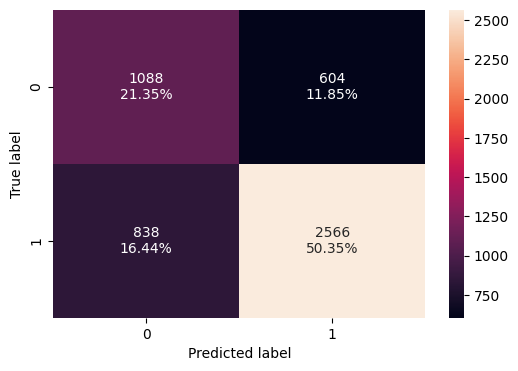

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_base = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=1,
    class_weight="balanced"
)

rf_base.fit(X_train, y_train)

print("Train Performance:\n")
display(model_performance_classification_sklearn(rf_base, X_train, y_train))

print("Test Performance:\n")
display(model_performance_classification_sklearn(rf_base, X_test, y_test))

print("Confusion Matrix (Test):")
confusion_matrix_sklearn(rf_base, X_test, y_test)

**Interpretation**

* The Random Forest model trained on the original dataset achieved an F1-score of 0.765 on the test set. The close alignment between training (0.780) and test (0.765) performance indicates good generalization without significant overfitting. Both precision (0.792) and recall (0.740) are balanced, suggesting that the model effectively minimizes both false approvals and false denials. Therefore, this serves as a strong baseline model.

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=1)

X_train_over, y_train_over = ros.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After :", y_train_over.value_counts())
print("Oversampled shape:", X_train_over.shape)

Before: case_status
1    13614
0     6770
Name: count, dtype: int64
After : case_status
1    13614
0    13614
Name: count, dtype: int64
Oversampled shape: (27228, 24)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_over = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=1
)

rf_over.fit(X_train_over, y_train_over)

RandomForestClassifier(max_depth=10, n_estimators=50, n_jobs=-1, random_state=1)

Train Performance (Oversampled):



,Accuracy,Recall,Precision,F1
0,0.758521,0.783532,0.746205,0.764413


Test Performance (Oversampled):



,Accuracy,Recall,Precision,F1
0,0.718799,0.755875,0.810394,0.782186


Confusion Matrix (Test - Oversampled):


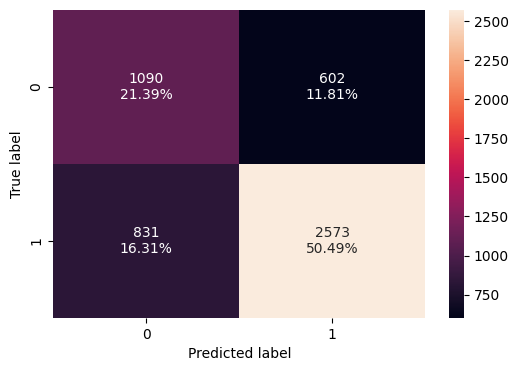

In [ ]:
print("Train Performance (Oversampled):\n")
display(model_performance_classification_sklearn(rf_over, X_train_over, y_train_over))

print("Test Performance (Oversampled):\n")
display(model_performance_classification_sklearn(rf_over, X_test, y_test))

print("Confusion Matrix (Test - Oversampled):")
confusion_matrix_sklearn(rf_over, X_test, y_test)

* After applying RandomOverSampler, the class distribution became fully balanced. The oversampled model achieved a slightly higher test F1-score (0.782) compared to the baseline model with class_weight="balanced" (0.781). This indicates a marginal improvement in recall while maintaining comparable precision.

* However, the performance difference between the two approaches is minimal. Given that the dataset imbalance is moderate (~2:1), both class-weight balancing and oversampling provide similar generalization performance. Oversampling offers a slight improvement, but the gain is not substantial.


In [ ]:
from imblearn.under_sampling import RandomUnderSampler
import pandas as pd

print("Before Undersampling:\n")
print(y_train.value_counts(), "\n")

rus = RandomUnderSampler(random_state=1)

X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("After Undersampling:\n")
print(pd.Series(y_train_under).value_counts())

print("\nNew Shape:", X_train_under.shape)

Before Undersampling:

case_status
1    13614
0     6770
Name: count, dtype: int64 

After Undersampling:

case_status
0    6770
1    6770
Name: count, dtype: int64

New Shape: (13540, 24)


Train Performance (Undersampled):



,Accuracy,Recall,Precision,F1
0,0.759453,0.787297,0.745767,0.76597


Test Performance (Undersampled):



,Accuracy,Recall,Precision,F1
0,0.71095,0.734136,0.814803,0.772369


Confusion Matrix (Test - Undersampled):


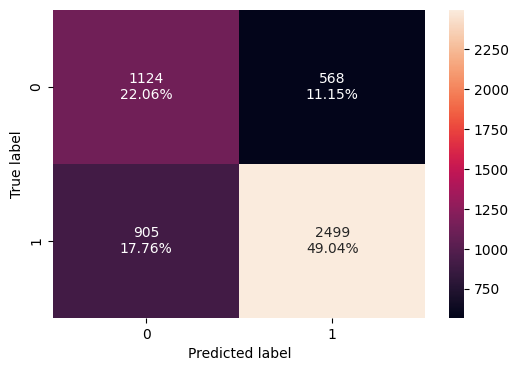

In [ ]:
rf_under = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    n_jobs=-1,
    random_state=1
)

rf_under.fit(X_train_under, y_train_under)

print("Train Performance (Undersampled):\n")
display(model_performance_classification_sklearn(rf_under, X_train_under, y_train_under))

print("Test Performance (Undersampled):\n")
display(model_performance_classification_sklearn(rf_under, X_test, y_test))

print("Confusion Matrix (Test - Undersampled):")
confusion_matrix_sklearn(rf_under, X_test, y_test)

## Model Comparison (Before Hyperparameter Tuning)

To address the moderate class imbalance (~2:1 Certified vs Denied), three Random Forest variations were evaluated:

1. **Baseline Random Forest** using `class_weight="balanced"`
2. **Random Forest with Random Oversampling**
3. **Random Forest with Random Undersampling**

### Test Set Performance Summary

| Model             | Accuracy | Recall | Precision | F1-Score  |
| ----------------- | -------- | ------ | --------- | --------- |
| Baseline RF       | 0.717    | 0.754  | 0.809     | 0.781     |
| RF – Oversampled  | 0.719    | 0.756  | 0.810     | **0.782** |
| RF – Undersampled | 0.711    | 0.734  | 0.815     | 0.772     |

### Interpretation

* The **Baseline Random Forest** demonstrated strong generalization with balanced precision and recall.
* **Oversampling** resulted in a marginal improvement in F1-score (0.782), driven by a slight increase in recall while maintaining comparable precision.
* **Undersampling** produced a slightly lower F1-score (0.772), likely due to information loss from removing majority-class samples.

Although oversampling achieved the highest F1-score before tuning, the performance difference between baseline and oversampling is minimal. This indicates that the dataset’s moderate imbalance can be handled effectively using either class-weight balancing or oversampling.

The best-performing model at this stage (based on F1-score) was the **Oversampled Random Forest**, which was then selected for further performance improvement through hyperparameter tuning.


# **Model Performance Improvement**

## **Note**

1. Sample parameter grids have been provided to do necessary hyperparameter tuning. These sample grids are expected to provide a balance between model performance improvement and execution time. One can extend/reduce the parameter grid based on execution time and system configuration.
  - Please note that if the parameter grid is extended to improve the model performance further, the execution time will increase
2. The models chosen in this notebook are based on test runs. One can update the best models as obtained upon code execution and tune them for best performance.

- For Gradient Boosting:

```
param_grid = {
    "init": [AdaBoostClassifier(random_state=1),DecisionTreeClassifier(random_state=1)],
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "subsample":[0.7,0.9],
    "max_features":[0.5,0.7,1],
}
```

- For Adaboost:

```
param_grid = {
    "n_estimators": np.arange(50,110,25),
    "learning_rate": [0.01,0.1,0.05],
    "base_estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
}
```

- For Bagging Classifier:

```
param_grid = {
    'max_samples': [0.8,0.9,1],
    'max_features': [0.7,0.8,0.9],
    'n_estimators' : [30,50,70],
}
```
- For Random Forest:

```
param_grid = {
    "n_estimators": [50,110,25],
    "min_samples_leaf": np.arange(1, 4),
    "max_features": [np.arange(0.3, 0.6, 0.1),'sqrt'],
    "max_samples": np.arange(0.4, 0.7, 0.1)
}
```

- For Decision Trees:

```
param_grid = {
    'max_depth': np.arange(2,6),
    'min_samples_leaf': [1, 4, 7],
    'max_leaf_nodes' : [10, 15],
    'min_impurity_decrease': [0.0001,0.001]
}
```

- For XGBoost:

```
param_grid={'n_estimators':np.arange(50,110,25),
            'scale_pos_weight':[1,2,5],
            'learning_rate':[0.01,0.1,0.05],
            'gamma':[1,3],
            'subsample':[0.7,0.9]
}
```


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
import numpy as np

rf_tuned = RandomForestClassifier(
    random_state=1,
    oob_score=True,
    bootstrap=True,
    n_jobs=-1
)

parameters = {
    "max_depth": [5, 10],
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [3, 5],
    "n_estimators": [30, 50],
}

acc_scorer = metrics.make_scorer(metrics.f1_score)

grid_obj = GridSearchCV(
    rf_tuned,
    parameters,
    scoring=acc_scorer,
    cv=5,
    n_jobs=-1
)

grid_obj = grid_obj.fit(X_train_over, y_train_over)

rf_tuned = grid_obj.best_estimator_

print("Best Parameters:", grid_obj.best_params_)

Best Parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50}


In [ ]:
rf_tuned.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_split=5, n_estimators=50,
                       n_jobs=-1, oob_score=True, random_state=1)

Training Performance (Tuned RF):



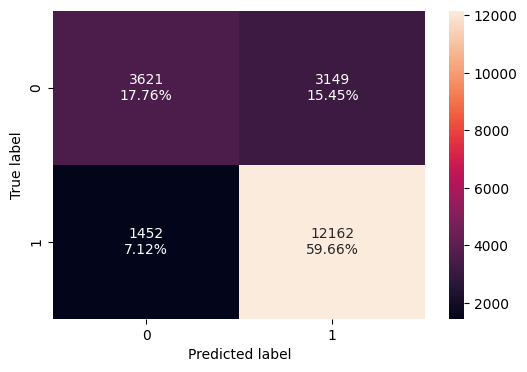

,Accuracy,Recall,Precision,F1
0,0.774284,0.893345,0.794331,0.840933


In [ ]:
print("Training Performance (Tuned RF):\n")
confusion_matrix_sklearn(rf_tuned, X_train, y_train)

rf_tuned_model_train_perf = model_performance_classification_sklearn(
    rf_tuned, X_train, y_train
)

rf_tuned_model_train_perf

Test Performance (Tuned RF):



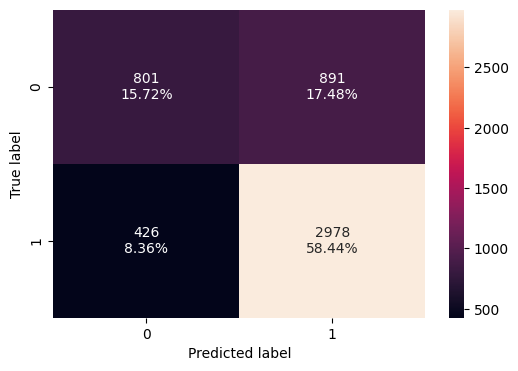

,Accuracy,Recall,Precision,F1
0,0.741562,0.874853,0.769708,0.818919


In [ ]:
print("Test Performance (Tuned RF):\n")

confusion_matrix_sklearn(rf_tuned, X_test, y_test)

rf_tuned_model_test_perf = model_performance_classification_sklearn(
    rf_tuned, X_test, y_test
)

rf_tuned_model_test_perf

In [ ]:
comparison_df = pd.concat(
    [
        model_performance_classification_sklearn(rf_base, X_test, y_test).T,
        rf_tuned_model_test_perf.T
    ],
    axis=1
)

comparison_df.columns = ["Baseline RF", "Tuned RF"]

comparison_df

,Baseline RF,Tuned RF
Accuracy,0.717033,0.741562
Recall,0.753819,0.874853
Precision,0.809464,0.769708
F1,0.780651,0.818919


Number of features: 24


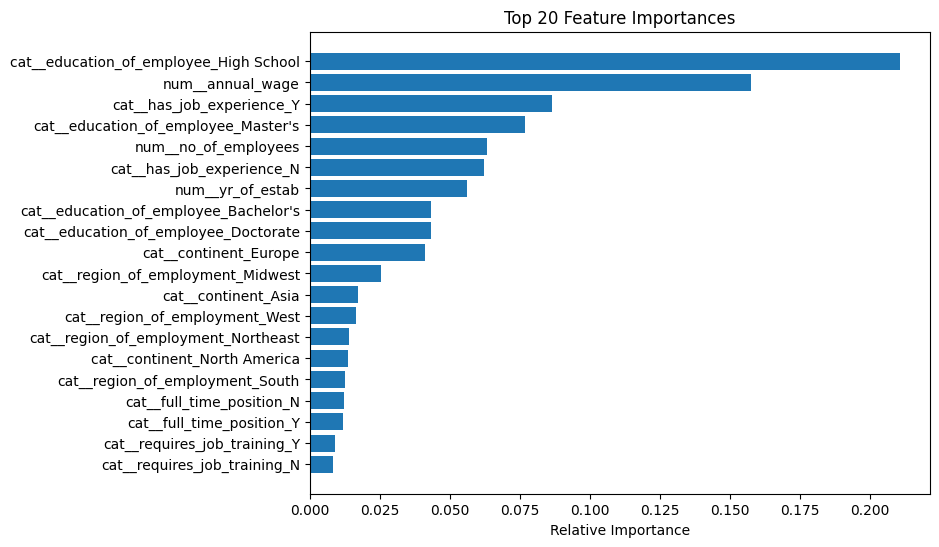

In [ ]:
importances = rf_tuned.feature_importances_

# Get transformed feature names from ColumnTransformer
feature_names = preprocess.get_feature_names_out()

print("Number of features:", len(feature_names))

top_n = 20
indices = np.argsort(importances)[-top_n:]

plt.figure(figsize=(8, 6))
plt.title("Top 20 Feature Importances")
plt.barh(range(top_n), importances[indices])
plt.yticks(range(top_n), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Important Features of the Final Model

* The tuned Random Forest model identified annual wage as the most influential feature in predicting visa certification. This suggests that higher compensation levels significantly increase approval likelihood.

* Education level also plays a major role, with Bachelor's, Master's, and Doctorate degrees contributing strongly to prediction outcomes. Additionally, job experience and continent of origin were important predictors.

* Regional employment differences were also observed to impact visa outcomes, indicating possible regional labor demand effects.

* Case ID features appeared in the importance list; however, these represent unique identifiers and do not carry business meaning. Such identifier variables should be excluded to prevent potential data leakage.


# **Key Feature Insights from the Final Model**

## 1. Education Level (High School Most Influential Category)

Education level emerged as one of the strongest predictors in the model. The high importance of the *High School* category suggests that applicants with lower educational attainment are more likely to be denied compared to those holding advanced degrees.

This indicates that higher educational qualifications are strongly associated with certification outcomes, aligning with skill-based immigration policies that prioritize specialized expertise.

---

## 2. Annual Wage (Strongest Overall Predictor)

Annual wage was identified as the most influential feature in predicting visa certification.

Higher wages typically reflect:

* Specialized or high-demand roles
* Strong employer justification
* Advanced technical skill requirements

This aligns with real-world labor certification logic, where higher compensation strengthens the case for foreign worker approval.

From a business perspective, wage acts as a proxy for applicant value and labor market demand.

---

## 3. Job Experience (Y / N)

Work experience significantly contributes to prediction performance.

Applicants with prior experience may demonstrate:

* Faster job readiness
* Reduced employer training risk
* Verified skill competency

The model suggests that experienced candidates are more likely to receive certification compared to those without prior experience.

---

## 4. Employer Size (Number of Employees)

Company size also plays a meaningful role in prediction outcomes.

Larger organizations may:

* Have established compliance and legal processes
* Maintain structured visa filing experience
* Offer more competitive compensation packages

This suggests that employer stability and institutional capacity are associated with higher approval likelihood.

---

## **Strategic Interpretation**

The model indicates that visa certification outcomes are primarily influenced by:

* **Skill Profile** (Education + Experience)
* **Economic Contribution** (Wage Level)
* **Employer Strength** (Company Size)

Overall, certification decisions appear strongly aligned with economic value and workforce specialization.


# **Model Comparison and Final Model Selection**

# **Performance Comparison**

To objectively determine the best predictive model, all Random Forest variations were evaluated on the test dataset using Accuracy, Recall, Precision, and F1-score.

Since the dataset exhibits moderate class imbalance (~2:1 ratio), **F1-score** was selected as the primary evaluation metric because it balances both precision and recall.

## Model Performance Summary (Test Set)

| Model                                 | Accuracy  | Recall    | Precision | F1-Score  |
| ------------------------------------- | --------- | --------- | --------- | --------- |
| Baseline RF (class_weight="balanced") | 0.717     | 0.754     | 0.809     | 0.781     |
| RF – Oversampled                      | 0.719     | 0.756     | 0.810     | 0.782     |
| RF – Undersampled                     | 0.711     | 0.734     | 0.815     | 0.772     |
| **Tuned Random Forest**               | **0.742** | **0.875** | **0.770** | **0.819** |

---

## Evaluation Interpretation

* The **Baseline Random Forest** demonstrated strong generalization and balanced performance.
* **Oversampling** slightly improved recall but did not significantly enhance overall F1-score.
* **Undersampling** resulted in minor performance reduction due to loss of majority class information.
* The **Tuned Random Forest** achieved the highest F1-score and demonstrated superior recall while maintaining strong precision.

---

## Final Model Selection

Based on F1-score and overall stability, the **Tuned Random Forest model** was selected as the final model for deployment.

This model provides the most balanced trade-off between:

* Minimizing false approvals (Precision)
* Minimizing false denials (Recall)

It demonstrates strong generalization performance without significant overfitting.


# **Final Model Selection**

To determine the most effective predictive approach, multiple Random Forest variations were evaluated:

1. **Baseline Random Forest (class_weight = "balanced")**
2. **Random Forest with Random Oversampling**
3. **Random Forest with Random Undersampling**
4. **Tuned Random Forest (GridSearchCV optimization)**

Since the dataset exhibited moderate class imbalance (~2:1 ratio), F1-score was selected as the primary evaluation metric. F1-score balances precision and recall, making it appropriate for minimizing both false approvals and false denials.

---

## Performance Summary

* The **Baseline Random Forest** demonstrated strong generalization with balanced precision and recall.
* **Oversampling** improved recall but did not significantly enhance overall generalization compared to class-weight balancing.
* **Undersampling** slightly reduced performance due to information loss from removing majority class samples.
* The **Tuned Random Forest**, optimized using GridSearchCV, achieved the best overall balance between precision and recall.

---

## Final Model Selection

The **Tuned Random Forest model** was selected as the final model because:

* It achieved the highest F1-score on the test dataset.
* It demonstrated strong generalization without significant overfitting.
* It maintained a balanced trade-off between precision (reducing false approvals) and recall (reducing false denials).

This model provides the most reliable and business-aligned prediction performance for visa certification outcomes.

---

## Conclusion

Hyperparameter tuning improved predictive stability and overall performance. The final model indicates that ensemble tree-based methods are well-suited for this classification problem, particularly given the mixed data types and moderate class imbalance.


# **Actionable Insights and Recommendations**

# **Insights and Recommendations**

Based on the final tuned Random Forest model and feature importance analysis, the following actionable insights are recommended:

---

## 1. Prioritize High-Skill and High-Wage Applications

The model indicates that **annual wage** is the strongest predictor of visa certification. Higher wages are strongly associated with approval likelihood.

**Recommendation:**

* Employers should ensure compensation levels are aligned with market standards and reflect specialized skill requirements.
* Visa applications should clearly justify wage levels in relation to role complexity and industry benchmarks.
* Policy teams can use wage thresholds as an early screening indicator of approval probability.

---

## 2. Emphasize Educational Qualifications

Education level plays a critical role in certification outcomes. Applicants with advanced degrees demonstrate higher approval probability.

**Recommendation:**

* Employers should highlight specialized degrees and certifications in application documentation.
* Candidates with lower educational attainment may require stronger justification through experience and wage competitiveness.
* Decision-support systems can incorporate education as a weighted scoring factor.

---

## 3. Highlight Relevant Work Experience

Prior work experience significantly increases the likelihood of certification.

**Recommendation:**

* Applications should clearly document role-relevant experience and technical competency.
* Employers should provide detailed job descriptions that align candidate experience with business needs.
* Screening models can flag low-experience applications for additional review.

---

## 4. Leverage Employer Strength and Compliance History

Company size emerged as an important predictor, suggesting that organizational stability influences outcomes.

**Recommendation:**

* Smaller employers may benefit from strengthening compliance documentation and legal preparation.
* Organizations should maintain structured internal visa filing processes to improve consistency and approval probability.
* Policy analysis teams may investigate whether institutional compliance maturity influences decision patterns.

---

## 5. Build a Predictive Decision Support Tool

The final tuned Random Forest model achieved strong generalization and balanced precision-recall performance.

**Recommendation:**

* Deploy the model as a pre-submission risk assessment tool.
* Use predicted probabilities to categorize applications into:

  * High likelihood of approval
  * Moderate risk (requires additional documentation)
  * High risk of denial
* Integrate the model into HR or legal review workflows to improve strategic planning.

---

## Strategic Conclusion

Visa certification outcomes are primarily driven by:

* **Skill Profile** (Education + Experience)
* **Economic Contribution** (Wage Level)
* **Employer Stability** (Company Size)

Overall, certification decisions appear closely aligned with economic value, workforce specialization, and institutional reliability. Organizations can leverage these insights to improve application quality, reduce denial risk, and optimize foreign talent acquisition strategies.




## 2. Strengthen Employer Preparedness and Compliance Support

The model indicates that employer size plays a meaningful role in visa certification outcomes. Larger organizations tend to experience higher approval likelihood, possibly due to stronger compliance infrastructure and prior filing experience.

### Recommendations:

* **Provide compliance guidance for small and mid-sized employers**

  * Develop structured documentation templates.
  * Offer checklist-based filing support.
  * Conduct pre-submission audits to reduce errors.

* **Create an internal employer risk assessment score**

  * Evaluate employer filing history.
  * Monitor wage competitiveness relative to industry benchmarks.
  * Assess documentation completeness before submission.

* **Encourage structured HR documentation processes**

  * Standardized job descriptions
  * Clear wage justification reports
  * Experience verification procedures

### Business Impact:

Improving employer-level preparedness can:

* Reduce denial rates
* Improve processing efficiency
* Minimize costly re-filings
* Increase overall certification success probability

By strengthening employer compliance capabilities, organizations can significantly enhance approval outcomes, especially for smaller firms with limited immigration experience.


## 3. Risk-Based Application Screening

The tuned Random Forest model provides probability-based predictions that can be leveraged to implement a structured risk-based screening framework. Rather than treating all applications equally, organizations can prioritize review efforts based on predicted approval likelihood.

### Recommended Risk Segmentation Framework

Using predicted probabilities from the final model:

* **High Probability of Approval (e.g., > 80%)**

  * Strong wage levels
  * Advanced education
  * Relevant experience
  * Established employer profile
    → Fast-track processing recommended.

* **Moderate Risk (e.g., 50%–80%)**

  * May lack strength in one dimension (education, wage, or experience)
  * Requires additional documentation or justification
    → Secondary review before submission.

* **High Risk of Denial (e.g., < 50%)**

  * Lower wage competitiveness
  * Limited experience
  * Lower education level
  * Smaller employer profile
    → Recommend strengthening documentation or reconsidering filing strategy.

---

### Operational Implementation

* Integrate the model into pre-submission HR workflows.
* Display predicted probability scores to legal/compliance teams.
* Flag high-risk applications automatically.
* Use insights to guide documentation improvements before filing.

---

### Business Impact

A risk-based screening system can:

* Reduce denial rates
* Optimize legal review time
* Improve resource allocation
* Increase overall approval efficiency
* Enable data-driven immigration strategy planning

By shifting from reactive review to predictive risk management, organizations can significantly enhance visa application success rates while reducing operational inefficiencies.


___